<div >
<img src = "figs/ans_banner_1920x200.png" />
</div>

# Caso-taller:  Recomendando el Blog de  Hernán Casciari 


[Hernán Casciari](https://hernancasciari.com/#bio), es un escritor argentino, que escribe blog posts con cuentos e historias  relacionadas con el futbol, su vida, infancia, y relaciones familiares con toques de ficción. Este [blog](https://hernancasciari.com/blog/) es  tan interesantes que en 2005 fue premiado como “El mejor blog del mundo” por Deutsche Welle de Alemania. 

El objetivo de este caso-taller es construir un sistema de recomendación basado en los contenidos de los posts utilizando similitud de las palabras usadas o temas de los cuentos.

## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "Revisión por el compañero."

4. El archivo entregado debe poder ser ejecutado localmente por los pares. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos  en la misma ruta de acceso del cuaderno, por ejemplo: `data`.

## LIBRERIAS

In [2]:
# BASICAS
import pandas as pd
import numpy as np


#SKITLEARN
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# GENSIM
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from gensim.models.ldamulticore import LdaMulticore

# PROC. TEXTO
import re
import unidecode
import spacy
from PyPDF2 import PdfReader


# VISUALIZACION
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pprint import pprint

C:\Users\danie\anaconda3\Lib\site-packages\PyPDF2\__init__.py:21: DeprecationWarning: PyPDF2 is deprecated. Please move to the pypdf library instead.
  warnings.warn(


## Desarrollo


### 1. Carga de datos 

En la carpeta `data` se encuentran el archivo `blog_casciari.csv` con el título, la fecha de publicación, y el contenido de los cuentos publicados en el blog  de sr. Casciari. Cargue estos datos en su *cuaderno* y reporte brevemente el contenido de la base.
   

In [5]:
# Utilice este espacio para escribir el código
ruta = 'data/blog_casciari.csv'
df = pd.read_csv(ruta)

In [6]:
print(df.head())

                       titulo    fecha  \
0            El rincón blanco  1/11/08   
1  Mínimos avances en la cama  1/24/08   
2                  Don Marcos  2/19/08   
3              Los dos rulfos  3/26/08   
4   La noticia no es el perro  4/15/08   

                                              cuento  
0  De pronto yo estaba en el hogar donde pasé la ...  
1  Menos la cama, todo ha mejorado en este mundo....  
2  Dos veces, y no una, mi abuelo materno me ayud...  
3  A su regreso de México, mi amigo Comequechu no...  
4  De repente, un video de You Tube recibe un mil...  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   titulo  520 non-null    object
 1   fecha   520 non-null    object
 2   cuento  520 non-null    object
dtypes: object(3)
memory usage: 12.3+ KB


In [8]:
df.shape

(520, 3)

Se realiza la carga del data set, entontrando 3 columnas: titulo, fecha y cuento, asociados a los blogs de Casciari. Se encuentra un total de 520 registros sin aparentes datos nulos.

### 2. Homogenización de textos

Para cumplir con el objetivo de generar recomendaciones en esta sección debe preparar los posts para poder ser utilizados en su sistema de recomendación. Para ello, "limpie" y "tokenize" cada uno de los cuentos, describiendo detalladamente los pasos que realizo y si transformó o eliminó ciertas palabras. Para asistirlo en la tarea he creado listas de *stopwords* que están disponibles en la carpeta `data`. En su procedimiento ilustre la limpieza con el cuento 'La venganza del metegol'. (En su limpieza recuerde que el objetivo es generar recomendaciones a partir de la similitud de las palabras o temas de los cuentos)

Para iniciar con el proceso de homogenización de la data, se imprime el texto que se tomará como referencia para el ejercicio. Titulo: La venganza del metegol. Esto se hace con el objetivo de tener una visión general del tipo de texto y caracteres con que nos vamos a encontrar.

In [12]:
print(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])

El mes pasado me invitaron a presentar un libro en Buenos Aires. Y como era un libro sobre fútbol, al final de la charla el director de la editorial nos invitó a jugar un partido de metegol (ese invento español al que sus creadores llaman, erróneamente, futbolín). Hacía años que no jugaba al metegol, pero por suerte me tocó de compañero un filósofo muy prestigioso y pudimos ganar. Nuestros contrincantes eran el autor del libro y el director de la editorial. De los tres, a este último lo conocía desde la juventud.
Jugamos dos partidos enteros y los destrozamos con una facilidad pasmosa: hacía años que no practicaba este falso deporte de muñecas y reflejos, pero descubrí que no había perdido las mañas. Eso me hizo sentir bien: a mi edad cualquier destreza que mantengamos indemne, por más pelotuda que sea, se convierte en una gran noticia.
Después de la charla algunos fotógrafos hicieron imágenes del partido de metegol y las subieron a Twitter.
— Estadio: Librería Gandhi, Buenos Aires. Lo

In [13]:
len(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])

6286

Dentro de la impresión de referencia se puede observar que cada elemento del campo "Cuento" tiene textos extensos y con caracteres especiales. Justamente con la eliminación de caracteres es el procedimiento con el que se continuará, utilizando la librería unidecode.

In [15]:
df['cuento'] = df['cuento'].apply(unidecode.unidecode)
print(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])

El mes pasado me invitaron a presentar un libro en Buenos Aires. Y como era un libro sobre futbol, al final de la charla el director de la editorial nos invito a jugar un partido de metegol (ese invento espanol al que sus creadores llaman, erroneamente, futbolin). Hacia anos que no jugaba al metegol, pero por suerte me toco de companero un filosofo muy prestigioso y pudimos ganar. Nuestros contrincantes eran el autor del libro y el director de la editorial. De los tres, a este ultimo lo conocia desde la juventud.
Jugamos dos partidos enteros y los destrozamos con una facilidad pasmosa: hacia anos que no practicaba este falso deporte de munecas y reflejos, pero descubri que no habia perdido las manas. Eso me hizo sentir bien: a mi edad cualquier destreza que mantengamos indemne, por mas pelotuda que sea, se convierte en una gran noticia.
Despues de la charla algunos fotografos hicieron imagenes del partido de metegol y las subieron a Twitter.
-- Estadio: Libreria Gandhi, Buenos Aires. L

In [16]:
len(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])

6297

Podemos observar que las tildes fueron eliminadas y que el tamaño del texto aumentó, esto se debe a que por ejemplo en "-Estadio" el unicode transforma el guión a su representación más cercana en ASCII, en este caso "--".

Ahora se procederá a la eliminación de caracteres como comas, guiones y demás caracteres especiales que no correspondan a un valor alfanumérico. Para esto se utilizará la expresión regular [^A-Za-z0-9 ]+

In [18]:
df['cuento'] = df['cuento'].apply(lambda x: re.sub(r'[^A-Za-z0-9 ]+', ' ', x))
df['cuento'] = df['cuento'].apply(lambda x: re.sub('\s+', ' ',x))
print(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])                                  

El mes pasado me invitaron a presentar un libro en Buenos Aires Y como era un libro sobre futbol al final de la charla el director de la editorial nos invito a jugar un partido de metegol ese invento espanol al que sus creadores llaman erroneamente futbolin Hacia anos que no jugaba al metegol pero por suerte me toco de companero un filosofo muy prestigioso y pudimos ganar Nuestros contrincantes eran el autor del libro y el director de la editorial De los tres a este ultimo lo conocia desde la juventud Jugamos dos partidos enteros y los destrozamos con una facilidad pasmosa hacia anos que no practicaba este falso deporte de munecas y reflejos pero descubri que no habia perdido las manas Eso me hizo sentir bien a mi edad cualquier destreza que mantengamos indemne por mas pelotuda que sea se convierte en una gran noticia Despues de la charla algunos fotografos hicieron imagenes del partido de metegol y las subieron a Twitter Estadio Libreria Gandhi Buenos Aires Locales A la izquierda Alej

<>:2: DeprecationWarning: invalid escape sequence '\s'
<>:2: DeprecationWarning: invalid escape sequence '\s'
C:\Users\danie\AppData\Local\Temp\ipykernel_24008\3549350535.py:2: DeprecationWarning: invalid escape sequence '\s'
  df['cuento'] = df['cuento'].apply(lambda x: re.sub('\s+', ' ',x))


In [19]:
len(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])

6115

Como se puede observar, todos los caracteres especiales fueron eliminados y el largo del texto referencia se redujo. Por ejemplo, los siguientes caracteres que se veían en el segmento de código anterior, ya no se ven: "(", ")", "<", ",", ".", entre otros. De igual forma, se eliminaron los espacios adicionales generados con la expresión regular '[^A-Za-z0-9 ]+'

In [21]:
df['cuento'] = df['cuento'].apply(lambda x: re.sub("\d+", "", x))
df['cuento'] = df['cuento'].apply(lambda x: re.sub('\s+', ' ',x))
df['cuento'] = df['cuento'].apply(lambda x: x.strip())
print(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])    

<>:1: DeprecationWarning: invalid escape sequence '\d'
<>:2: DeprecationWarning: invalid escape sequence '\s'
<>:1: DeprecationWarning: invalid escape sequence '\d'
<>:2: DeprecationWarning: invalid escape sequence '\s'


El mes pasado me invitaron a presentar un libro en Buenos Aires Y como era un libro sobre futbol al final de la charla el director de la editorial nos invito a jugar un partido de metegol ese invento espanol al que sus creadores llaman erroneamente futbolin Hacia anos que no jugaba al metegol pero por suerte me toco de companero un filosofo muy prestigioso y pudimos ganar Nuestros contrincantes eran el autor del libro y el director de la editorial De los tres a este ultimo lo conocia desde la juventud Jugamos dos partidos enteros y los destrozamos con una facilidad pasmosa hacia anos que no practicaba este falso deporte de munecas y reflejos pero descubri que no habia perdido las manas Eso me hizo sentir bien a mi edad cualquier destreza que mantengamos indemne por mas pelotuda que sea se convierte en una gran noticia Despues de la charla algunos fotografos hicieron imagenes del partido de metegol y las subieron a Twitter Estadio Libreria Gandhi Buenos Aires Locales A la izquierda Alej

C:\Users\danie\AppData\Local\Temp\ipykernel_24008\345120463.py:1: DeprecationWarning: invalid escape sequence '\d'
  df['cuento'] = df['cuento'].apply(lambda x: re.sub("\d+", "", x))
C:\Users\danie\AppData\Local\Temp\ipykernel_24008\345120463.py:2: DeprecationWarning: invalid escape sequence '\s'
  df['cuento'] = df['cuento'].apply(lambda x: re.sub('\s+', ' ',x))


In [22]:
len(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])

6097

Como se puede observar, el tamaño de cada cuento se sigue reduciendo. En este caso se han eliminado los números, los cuales no se considera que agreguen información relevante para el ejercicio de temas que se realizará posteriormente.

A continuación, se procederá con la transformación de todos los cuentos a minúscula, con el fin de homogenizar aún más el texto.

In [31]:
df['cuento'] = df['cuento'].apply(lambda x: x.lower())
print(df.loc[df['titulo']=="La venganza del metegol", "cuento"].iloc[0])   

el mes pasado me invitaron a presentar un libro en buenos aires y como era un libro sobre futbol al final de la charla el director de la editorial nos invito a jugar un partido de metegol ese invento espanol al que sus creadores llaman erroneamente futbolin hacia anos que no jugaba al metegol pero por suerte me toco de companero un filosofo muy prestigioso y pudimos ganar nuestros contrincantes eran el autor del libro y el director de la editorial de los tres a este ultimo lo conocia desde la juventud jugamos dos partidos enteros y los destrozamos con una facilidad pasmosa hacia anos que no practicaba este falso deporte de munecas y reflejos pero descubri que no habia perdido las manas eso me hizo sentir bien a mi edad cualquier destreza que mantengamos indemne por mas pelotuda que sea se convierte en una gran noticia despues de la charla algunos fotografos hicieron imagenes del partido de metegol y las subieron a twitter estadio libreria gandhi buenos aires locales a la izquierda alej

Ahora ya cada uno de los cuentos se ve mucho más homogeneo y limpio. Se procederá ahora con una tokenización apoyado en la libreria spacy.

In [33]:
nlp = spacy.load("es_core_news_sm")

df['doc'] = df['cuento'].apply(lambda x: nlp(x))
print(df.loc[df['titulo']=="La venganza del metegol", "doc"].iloc[0])    

el mes pasado me invitaron a presentar un libro en buenos aires y como era un libro sobre futbol al final de la charla el director de la editorial nos invito a jugar un partido de metegol ese invento espanol al que sus creadores llaman erroneamente futbolin hacia anos que no jugaba al metegol pero por suerte me toco de companero un filosofo muy prestigioso y pudimos ganar nuestros contrincantes eran el autor del libro y el director de la editorial de los tres a este ultimo lo conocia desde la juventud jugamos dos partidos enteros y los destrozamos con una facilidad pasmosa hacia anos que no practicaba este falso deporte de munecas y reflejos pero descubri que no habia perdido las manas eso me hizo sentir bien a mi edad cualquier destreza que mantengamos indemne por mas pelotuda que sea se convierte en una gran noticia despues de la charla algunos fotografos hicieron imagenes del partido de metegol y las subieron a twitter estadio libreria gandhi buenos aires locales a la izquierda alej

In [41]:
print(df.loc[df['titulo']=="La venganza del metegol"].iloc[0])    

titulo                              La venganza del metegol
fecha                                              11/17/15
cuento    el mes pasado me invitaron a presentar un libr...
doc       (el, mes, pasado, me, invitaron, a, presentar,...
Name: 160, dtype: object


Se crea una columna dentro del dataframe sobre la cual se almacenará el objeto spaCY y se realiza una visualización del mismo. Adicionalmente se puede observar cómo creó los token y los almacenó en la columna "doc" dentro del dataframe.

A continuación, se cargarán los archivos de stopwords para ser utilizados en la última parte de limpieza y tokenización.

In [42]:
stopwords1 = pd.read_csv("data/extra_stopwords.csv", header=None)[0].str.lower().tolist()
stopwords2 = pd.read_csv("data/stopwords_taller.csv", header=None)[0].str.lower().tolist()

stopwords_custom = set(stopwords1 + stopwords2)

nlp.Defaults.stop_words |= stopwords_custom

In [46]:
def remove_stopwords(doc):
    return [token.text for token in doc if not token.is_stop]

df["tokens"] = df["doc"].apply(lambda doc: remove_stopwords(doc))

In [48]:
print(df.loc[df['titulo']=="La venganza del metegol", "tokens"].iloc[0])

['mes', 'invitaron', 'presentar', 'libro', 'aires', 'libro', 'futbol', 'charla', 'director', 'editorial', 'invito', 'jugar', 'partido', 'metegol', 'invento', 'espanol', 'creadores', 'llaman', 'erroneamente', 'futbolin', 'anos', 'jugaba', 'metegol', 'suerte', 'toco', 'companero', 'filosofo', 'prestigioso', 'pudimos', 'ganar', 'contrincantes', 'autor', 'libro', 'director', 'editorial', 'conocia', 'juventud', 'jugamos', 'partidos', 'enteros', 'destrozamos', 'facilidad', 'pasmosa', 'anos', 'practicaba', 'falso', 'deporte', 'munecas', 'reflejos', 'descubri', 'perdido', 'manas', 'sentir', 'edad', 'destreza', 'mantengamos', 'indemne', 'pelotuda', 'convierte', 'noticia', 'charla', 'fotografos', 'imagenes', 'partido', 'metegol', 'subieron', 'twitter', 'estadio', 'libreria', 'gandhi', 'aires', 'locales', 'izquierda', 'alejandro', 'duchini', 'gonzalo', 'garces', 'vistantes', 'derecha', 'tomas', 'abraham', 'hernan', 'casciari', 'resultado', 'match', 'match', 'paliza', 'volvi', 'casa', 'recibi', 'm

In [50]:
len(df.loc[df['titulo']=="La venganza del metegol", "tokens"].iloc[0])

466

In [55]:
df["tokens"] = df["tokens"].apply(lambda x: " ".join(x))

In [57]:
print(df.loc[df['titulo']=="La venganza del metegol"].iloc[0])    

titulo                              La venganza del metegol
fecha                                              11/17/15
cuento    el mes pasado me invitaron a presentar un libr...
doc       (el, mes, pasado, me, invitaron, a, presentar,...
tokens    mes invitaron presentar libro aires libro futb...
Name: 160, dtype: object


Se creó como una nueva columna dentro del dataframe, el texto tokenizado con stopwords. Para ello se utilizaron las default stopwords de spacy. Como insumo principal se utilizaron los stopwords dados para el ejercicio. Como resultado, se puede observar que para el titulo de referencia, el número de elementos se redujo a 466, lo cual nos muestra que la limpieza sobre el texto ha sido exhaustiva y rigurosa.

Para los próximos ejercicios, se utilizará la columna "tokens" del dataframe como elemento de referencia para generar recomendaciones. Como paso final se lematizará el texto para darle una mayor profundidad a la normalización del texto

In [60]:
df["tokens"] = df["tokens"].apply(lambda x: " ".join([token.lemma_ for token in nlp(x)]))

In [62]:
print(df.loc[df['titulo']=="La venganza del metegol", "tokens"].iloc[0])

mes invitar presentar libro aires libro futbol char él director editorial invito jugar partido metegol invento espanol creador llamar erroneamente futbolin ano jugar metegol suerte tocar companerir filosofo prestigioso pudimos ganar contrincant autor libro director editorial conocio juventud jugamos partido entero destrozar facilidad pasmós ano practicar falso deporte muneca reflejo descubri perdido mana sentir edad destreza mantener indemne pelotuda convertir noticia char él fotografo imagen partido metegol subir twitter estadio librerio gandhi aires local izquierdo alejandro duchini gonzalo garz vistant derecho toma abraham hernar casciari resultado match match paliza volvi casa recibi mail chiri amigo infancia decio visto foto sorprendiar companero filosofo admirabar juventud vo jugar metegol tomar abraham pasar sueno decia momento partido imagine diecisiete ano mirar ventana librerio gandhi escena futuro sonrei recuerdo momentaneo desconcentro juego justo momento gol unico recibi n

### 3. Generando Recomendaciones

En esta sección nos interesa generar recomendaciones de cuentos en el blog a un usuario que leyó 'La venganza del metegol'. Para ello vamos a utilizar distintas estrategias.

#### 3.1. Recomendaciones basadas en contenidos

##### 3.1.1. Genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para el cuento 'La venganza del metegol' usando en la distancia de coseno donde el texto este vectorizado por `CountVectorizer`. Explique el procedimiento que realizó y como ordenó las recomendaciones.

In [127]:
# Utilice este espacio para escribir el código.
count = CountVectorizer()
count_matrix = count.fit_transform(df['tokens'])
count_matrix

<520x24631 sparse matrix of type '<class 'numpy.int64'>'
	with 134530 stored elements in Compressed Sparse Row format>

In [119]:
cosine_sim2 = cosine_similarity(count_matrix, count_matrix)
cosine_sim2

array([[1.        , 0.1874824 , 0.31836955, ..., 0.13870547, 0.20865211,
        0.32861325],
       [0.1874824 , 1.        , 0.25231654, ..., 0.22368186, 0.19140607,
        0.23037577],
       [0.31836955, 0.25231654, 1.        , ..., 0.19057712, 0.21178976,
        0.33247012],
       ...,
       [0.13870547, 0.22368186, 0.19057712, ..., 1.        , 0.12974301,
        0.1436507 ],
       [0.20865211, 0.19140607, 0.21178976, ..., 0.12974301, 1.        ,
        0.26143527],
       [0.32861325, 0.23037577, 0.33247012, ..., 0.1436507 , 0.26143527,
        1.        ]])

In [121]:
def recomendador(title, cosine_sim, df=df):
    
    #Paso 2
    df = df.reset_index()
    indices = pd.Series(df.index, index=df['titulo']).drop_duplicates()
    #Paso 3
    idx = indices[title]

    #Paso 4
    sim_scores = list(enumerate(cosine_sim[idx]))

    #Paso 5
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    #Paso 6
    sim_scores = sim_scores[1:6]

    movie_indices = [i[0] for i in sim_scores]
    indices_recom = [i[1] for i in sim_scores]

    #Paso 7
    # return df['titulo'].iloc[movie_indices]
    return pd.DataFrame({
        "Puesto": range(1, 6),
        "Recomendación": df['titulo'].iloc[movie_indices].values,
        "Similitud": indices_recom
    })

In [123]:
recom_count=recomendador('La venganza del metegol', cosine_sim=cosine_sim2, df=df)

El procedimiento realizado para abordar el punto es el siguiente:

1. Vectorización
Se convierten los textos (se toma el campo tokens con textos ya limpios) en una matriz de frecuencias con CountVectorizer, usando las stopwords del vectorizador.

2. Similitud de coseno
Se calcula la similitud de coseno entre cada par de cuentos.

3. Función recomendadora
Se crea una función recomendadora a la cual se le entrega el titulo a recomendar, la similitud de coseno y el dataframe. Se localiza el índice del cuento base (La venganza del metegol).
    - Se toman los puntajes de similitud de ese cuento con todos los demás.
    - Se ordenan esos puntajes de mayor a menor.
    - Se descarta el primero porque es el mismo cuento (similaridad = 1).
    - Se seleccionan los siguientes que serán los cuentos a recomendar

De esta manera se obtienen los cuentos a recomendar:

In [125]:
recom_count

,Puesto,Recomendación,Similitud
0,1,Cuento con bruja y tramontina,0.350494
1,2,Una línea de puntos en un libro de catecismo,0.326309
2,3,"Dice el Chiri, dice el Gordo",0.315441
3,4,El milagro de los pueblos,0.303420
4,5,Abrir y cerrar un círculo,0.294358


##### 3.1.2. Genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para  el cuento 'La venganza del metegol' usando nuevamente la distancia de coseno, pero ahora vectorice el texto usando `TF-IDFVectorizer`. Explique el procedimiento que realizó y como ordenó las recomendaciones. Compare con los resultados del punto anterior y explique sus similitudes y/o diferencias.

In [145]:
# Utilice este espacio para escribir el código.
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['tokens'])
tfidf_matrix

<520x24631 sparse matrix of type '<class 'numpy.float64'>'
	with 134530 stored elements in Compressed Sparse Row format>

In [157]:
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), index=df['titulo'], columns=tfidf.get_feature_names_out())
df_tfidf

,aamir,abacaaado,abajo,abalanzar,abalanzo,abananado,abandonado,abandonar,abandono,abandón,...,zurdazo,zurdito,zurdo,zurraba,zurrar,zurrartir,án,él,ós,ús
titulo,,,,,,,,,,,,,,,,,,,,,
El rincón blanco,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.101730,0.0,0.0
Mínimos avances en la cama,0.0,0.0,0.023332,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.053200,0.0,0.0
Don Marcos,0.0,0.0,0.016147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.055224,0.0,0.0
Los dos rulfos,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.060444,0.0,0.0
La noticia no es el perro,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.024182,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Instrucciones para la masturbación del hijo,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.078120,0.0,0.0
El colmo de un campesino,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.053738,0.0,0.0
La decadencia del Hombre Corbata,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.061088,0.0,0.0


In [147]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)
cosine_sim

array([[1.        , 0.06347447, 0.14653417, ..., 0.04793095, 0.07976438,
        0.12963445],
       [0.06347447, 1.        , 0.10086022, ..., 0.07923532, 0.05470566,
        0.07184729],
       [0.14653417, 0.10086022, 1.        , ..., 0.06866817, 0.08620809,
        0.13631786],
       ...,
       [0.04793095, 0.07923532, 0.06866817, ..., 1.        , 0.04740162,
        0.04591531],
       [0.07976438, 0.05470566, 0.08620809, ..., 0.04740162, 1.        ,
        0.10093271],
       [0.12963445, 0.07184729, 0.13631786, ..., 0.04591531, 0.10093271,
        1.        ]])

In [149]:
recom_tfidf=recomendador('La venganza del metegol', cosine_sim=cosine_sim, df=df)

El procedimiento realizado para abordar el punto es el siguiente:

1. Vectorización
Se convierten los textos (se toma el campo tokens con textos ya limpios) en una matriz de frecuencias con TfidfVectorizer, usando las stopwords del vectorizador.

2. Similitud de coseno
Se utiliza la similitud de coseno calculada en el punto anterior.

3. Función recomendadora
Se utiliza la misma función recomendadora desarrollada en el punto anterior


Aunque en el dataframe se encontraron palabras que se podrían lematizar, dado que ya se aplicó un proceso de lematización, no se hará ningún tratamiento adicional, dado que requeriría un ejercicio más exhausto mirando todas las palabras y no solamente las de muestra que se presentan con el método .head()

De esta manera se obtienen los cuentos a recomendar:

In [151]:
recom_tfidf

,Puesto,Recomendación,Similitud
0,1,Una línea de puntos en un libro de catecismo,0.156901
1,2,Cuento con bruja y tramontina,0.156378
2,3,Abrir y cerrar un círculo,0.123579
3,4,"Dice el Chiri, dice el Gordo",0.123546
4,5,La foto de Wasmosy,0.121822


Con base en las dos recomendaciones hasta ahora encontradas, podemos inferir:

1. Se tienen cuatro recomendaciones similares dentro del top 5 para los dos vectorizadores: Cuento con bruja y tramontina, Abrir y cerrar un círculo, Una línea de puntos en un libro de catecismo y Dice el Chiri, dice el Gordo
2. A pesar de tener estas mismas 4 recomendaciones dentro del top 5, todas tienen una similitud diferente según el método. En todos los casos se tuvo una similitud mayor usando el Countvectorized
3. Con el vectorizador de TfidfVectorizer no se tiene como recomendaciones el cuentos: El milagro de los pueblos, el cual presenta una similitud de 0.30 con el vectorizador Countvectorized
4. Con el vectorizador de TfidfVectorizer se tiene ahora una nueva recomendacion: La foto de Wasmosy con una similitud de 0.1218

##### 3.1.3. Genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para el cuento 'La venganza del metegol' usando el texto vectorizado por `TF-IDFVectorizer` y la correlación como medida de similitud. Explique el procedimiento que realizó y como ordenó las recomendaciones. Compare con los resultados de los puntos anteriores y explique sus similitudes y/o diferencias.

In [160]:
# Utilice este espacio para escribir el código.
corr_matrix = df_tfidf.T.corr(method='pearson')

In [162]:
def recomendador_corr(title, corr_matrix):
    sim_scores = corr_matrix[title].drop(title) 
    sim_scores = sim_scores.sort_values(ascending=False).head(5)
    return  pd.DataFrame({
        'Puesto': range(1, len(sim_scores)+1),
        'Recomendación': sim_scores.index,
        'Similitud': sim_scores.values
    })

In [164]:
recom_tfidf_corr = recomendador_corr('La venganza del metegol', corr_matrix)

Para abordar el punto se siguió el procedimiento:

1. Se reutiliza la matriz tfdif calculada en el punto anterior
2. Se calcula la matriz de correlación con base en el método pearson
3. se crea una nueva función recomendadora que hace:
   - Elimina el titulo a generar recomendaciones
   - Calcula las similitudes con base en la matriz de correlación calculada
   - Devuelve las recomendaciones con su respectivo score

A partir de este procedimiento se llega a las siguientes recomendaciones:

In [166]:
recom_tfidf_corr

,Puesto,Recomendación,Similitud
0,1,Una línea de puntos en un libro de catecismo,0.151649
1,2,Cuento con bruja y tramontina,0.148056
2,3,La foto de Wasmosy,0.116451
3,4,Abrir y cerrar un círculo,0.115722
4,5,Los jefes y los empleados,0.115089


Con base en estas nuevas recomendaciones podemos inferir que:

1. Se tienen cuatro recomendaciones similares dentro del top 5 para los dos vectorizadores TfidfVectorizer (uno con similitud de cosenos y otro con correlación): Cuento con bruja y tramontina, Abrir y cerrar un círculo, Una línea de puntos en un libro de catecismo y La foto de Wasmosy
2. A pesar de tener estas mismas 4 recomendaciones dentro del top 5, todas tienen una similitud diferente según el método. En todos los casos se tuvo una similitud mayor usando el TfidfVectorizer con matriz de correlación, aunque las diferencias no son significativas
3. Con el vectorizador de TfidfVectorizer - Correlación no se tiene como recomendaciones el cuento: Dice el Chiri, dice el Gordo, el cual presenta una similitud de 0.123 con el vectorizador TfidfVectorizer - Similitud de coseno
4. Con el vectorizador de TfidfVectorizer - Correlación se tiene ahora una nueva recomendacion: Los jefes y los empleados con una similitud de 0.115
5. La nueva recomendación que se obtuvo con el método TfidfVectorizer - Correlación tampoco se encuentra dentro de las recomendaciones arrojadas por el método CountVectorized.

##### 3.2. Recomendaciones basadas en temas

Usando modelado de temas con LDA, encuentre los temas subyacentes en el blog. Explique como eligió el numero óptimo de temas. Utilizando el tema asignado al cuento 'La venganza del metegol' y la probabilidad de pertenecer a este tema genere 5 recomendaciones de más recomendada (1) a menos recomendada (5) para este cuento. Explique el procedimiento que realizó. Compare con los resultados encontrados anteriormente y explique sus similitudes y/o diferencias. (Esto puede tomar mucho tiempo y requerir mucha capacidad computacional, puede aprovechar los recursos de [Google Colab](https://colab.research.google.com/))


In [195]:
# Utilice este espacio para escribir el código.
text_lda = df['tokens'].apply(lambda x: x.split()).tolist()
dictionary =Dictionary(text_lda)
dictionary

In [197]:
dictionary.filter_extremes(no_below=20, no_above=0.5)

In [203]:
corpus = [dictionary.doc2bow(doc) for doc in text_lda]

In [205]:
print('Numero de palabras únicas: %d' % len(dictionary))

Numero de palabras únicas: 1323


In [207]:
def calcular_coherencia(dictionary, corpus, texts, start=1, limit=10, step=1):
 
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
        model = LdaMulticore(corpus=corpus,
                        id2word=dictionary,
                        num_topics=num_topics, 
                        random_state=123,
                        passes=20)
        model_list.append(model)
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values

In [213]:
modelos, valores_c = calcular_coherencia(dictionary=dictionary, corpus=corpus, texts=text_lda, start=4, limit=15, step=1)

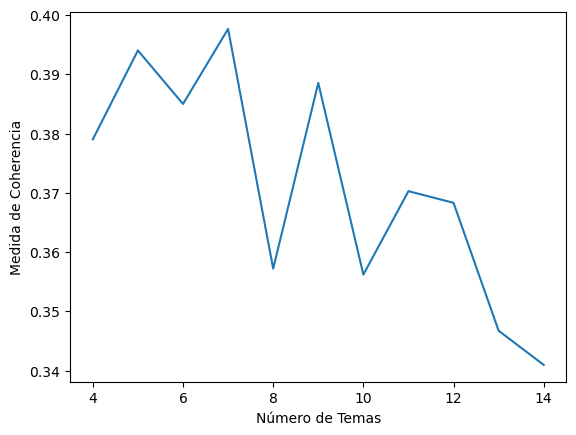

In [216]:
limit=15; start=4; step=1;
x = range(start, limit, step)
plt.plot(x, valores_c)
plt.xlabel("Número de Temas")
plt.ylabel("Medida de Coherencia")
plt.show()

In [218]:
lda_model_opt = LdaMulticore(corpus = corpus,
    id2word = dictionary,
    num_topics = 7,
    random_state=123)
pyLDAvis.enable_notebook()
LDA_visualization = gensimvis.prepare(lda_model_opt, corpus, dictionary)
LDA_visualization

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5     -0.009937 -0.004382       1        1  23.412773
3      0.001153  0.002627       2        1  17.760840
6      0.000026 -0.001614       3        1  15.822916
1     -0.000011  0.000003       4        1  15.441856
4      0.005527 -0.003598       5        1  13.435011
0      0.004955 -0.002206       6        1   8.835142
2     -0.001714  0.009170       7        1   5.291462, topic_info=          Term        Freq       Total Category  logprob  loglift
187        ojo  472.000000  472.000000  Default  30.0000  30.0000
108       foto  236.000000  236.000000  Default  29.0000  29.0000
702       loco  211.000000  211.000000  Default  28.0000  28.0000
245      sueno  189.000000  189.000000  Default  27.0000  27.0000
233      salir  324.000000  324.000000  Default  26.0000  26.0000
..         ...         ...         ...      ...      ...      ...
127       hijo   19.909994  478.647223   Topic7  -5.5588  -0.2407
404  argentino   19.036425  436.544408   Topic7  -5.6037  -0.1935
165       mano   18.541217  417.215751   Topic7  -5.6301  -0.1745
262      viejo   18.378007  469.188485   Topic7  -5.6389  -0.3008
259      venir   17.819843  371.097822   Topic7  -5.6697  -0.0971

[521 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
3         1  0.139342  absurdo
3         2  0.243848  absurdo
3         3  0.174177  absurdo
3         4  0.139342  absurdo
3         5  0.104506  absurdo
...     ...       ...      ...
576       3  0.109037   zapato
576       4  0.163556   zapato
576       5  0.109037   zapato
576       6  0.081778   zapato
576       7  0.109037   zapato

[2149 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 4, 7, 2, 5, 1, 3])

In [220]:
idx_cuento = df[df['titulo'] == 'La venganza del metegol'].index[0]
bow_cuento = corpus[idx_cuento]
temas_cuento = lda_model_opt.get_document_topics(bow_cuento)
tema_principal = max(temas_cuento, key=lambda x: x[1])[0]

In [222]:
prob_tema_principal = []
for i, bow in enumerate(corpus):
    doc_topics = dict(lda_model_opt.get_document_topics(bow))
    prob = doc_topics.get(tema_principal, 0)  # si no tiene, probabilidad = 0
    prob_tema_principal.append(prob)

df_recom = df[['titulo']].copy()
df_recom['prob_tema'] = prob_tema_principal

df_recom = df_recom[df_recom['titulo'] != 'La venganza del metegol']
df_recom = df_recom.sort_values('prob_tema', ascending=False)

In [224]:
top5_recom = df_recom.head(5)
top5_recom

,titulo,prob_tema
331,El Zacarías descubre al Zacarías,0.996638
307,De repente la vejez,0.996529
225,Una cena demasiado larga,0.996398
263,Gente de buen apellido,0.996051
319,Y el abuelo un día...,0.996015


El procedimiento realizado para abordar el ejercicio, fue:

1. **Preparación de los textos**
    - Se partió de la columna tokens del DataFrame, que contiene los cuentos ya limpiados, lematizados y sin stopwords.
    - Cada cuento se transformó en una lista de palabras "text_lda" para que pueda ser procesado por Gensim.
    - Se creó un diccionario (Dictionary) a partir de todos los tokens y se filtraron los términos extremos con filter_extremes(no_below=20, no_above=0.5), eliminando palabras muy raras o demasiado frecuentes.
    - Finalmente, se construyó el corpus como lista de Bag-of-Words de cada documento/cuento.

2. **Elección del número óptimo de temas**
    Para determinar el número de temas, se definió la función calcular_coherencia, que:
    - Entrena múltiples modelos LDA con distintos números de temas (del 4 al 14 en este caso).
    - Calcula la coherencia (c_v) de cada modelo, que mide cuán semánticamente consistente es cada tópico.
    - Se compararon los valores de coherencia y se eligió el número de temas con mayor coherencia promedio.
    - En este caso, el número óptimo resultó ser 7 temas, ya que maximiza la coherencia y mantiene los tópicos interpretables.

3. **Entrenamiento del modelo LDA final**
    - Se entrenó el modelo LDA con num_topics=7 usando LdaMulticore.
    - Se generó una visualización interactiva con pyLDAvis para explorar los tópicos, su tamaño relativo y la relación entre ellos.

4. **Generación de recomendaciones usando el tema del cuento objetivo**
    - Se identificó el cuento “La venganza del metegol” y se extrajo su distribución de temas (lda_model_opt.get_document_topics).
    - Se determinó el tema principal del cuento, es decir, el tema con mayor probabilidad.
    - Para cada cuento del corpus, se calculó la probabilidad de pertenecer a ese mismo tema.
    - Se creó un DataFrame con los títulos de los cuentos y la probabilidad de pertenencia al tema principal.
    - Se ordenó de mayor a menor probabilidad y se excluyó el cuento original.
    - Finalmente, se seleccionaron los 5 cuentos con mayor probabilidad como recomendaciones, de más recomendada (1) a menos recomendada (5)
      
5. **Comparación con recomendaciones anteriores**
    - En métodos basados en similitud de palabras (CountVectorizer o TF-IDF), las recomendaciones se basan en la cercanía de contenido textual general.
    - Con modelado de temas, las recomendaciones se basan en la pertenencia al mismo tema subyacente, lo que permite capturar similitudes semánticas más profundas.
    - Por eso, algunas recomendaciones pueden coincidir con las anteriores y otras pueden ser diferentes, dependiendo de si el contenido textual explícito coincide con la temática latente.

Finalmente, las recomendaciones que se obtuvieron con el modelo LDA, no tienen ninguna relación con las obtenidas con los métodos anteriores, pero las 5 obtenidas tuvieron una probabilidad igual o superior al 99%

### 4 Recomendaciones generales

De acuerdo con los resultados encontrados, en su opinión ¿qué procedimiento generó las mejores recomendaciones para la entrada elegida? ¿Cómo implementaría una evaluación objetiva de estas recomendaciones? Justifique su respuesta.

Desde mi punto de vista, el mejor procedimiento para generar recomendaciones para el cuento *“La venganza del metegol”* es el modelado de temas con LDA dado que:
- El modelado de temas con LDA genera recomendaciones más relevantes que los métodos basados únicamente en similitud de palabras (CountVectorizer o TF-IDF).
- LDA captura la estructura semántica latente, identificando tópicos compartidos entre cuentos, incluso si no comparten exactamente las mismas palabras.
- Por el contrario, la similitud de coseno o correlación sobre vectores de palabras puede favorecer coincidencias superficiales en términos frecuentes o stopwords residuales, perdiendo la relación temática real.
- LDA permite captar similitudes de temas subyacentes, mientras que los métodos tradicionales pueden centrarse solo en coincidencias léxicas.
- Las recomendaciones dadas por el modelo LDA, arrojó resultados con probabilidades muy altas (iguales o superiores al 99%) lo cual dá una efectividad considerable

Una manera de implementar una evaluación objetiva de estas recomendaciones puede ser a través de:
- Revisión de expertos de cada una de las recomendaciones y que ellos determinen el grado de acertividad de cada uno de los métodos
- Comparar los cuentos recomendados con embeddings más robustos y entrenados con mayor información, que nos podrían dar una evaluación más objetiva